**COMPETICAO ML PARA PREDICAO DE VINHOS - NEURON**
# Requisitos de Instalação
- Basta rodar o arquivo `install.bat` no cmd ou terminal, ele já contem todas as dependencias utilizadas no projeto

# Dependências Utilizadas
* Conforme requisitado no MarkDown de Explicação do projeto, as dependências utilizadas são:
* Pandas (Tratamento de dados e arquivos)
* Numpy (Funções matemáticas)
* Matplotlib (Vizualização de dados)
* Seaborn (Vizualização de dados)
* Scikit-learn (Machine Learning) #tive que substituir o sklearn por scikit-learn 



### Importação 


In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, IsolationForest
from sklearn.cluster import KMeans
from sklearn import metrics
from scipy.spatial.distance import cdist
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Leitura e Analise de Dados do `Train.csv`

In [83]:
train = pd.read_csv("train.csv",na_values = '-', index_col= 0) #Usa a coluna Id do CSV como a coluna Id do Data Structure do Pandas
matriz_treinamento = train.values
train

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
id,,,,,,,,,,,,
0,9.3,0.40,0.34,2.1,0.088,14.0,28.0,0.99940,3.44,0.84,12.2,7.0
1,8.3,0.38,0.33,1.8,0.070,5.0,15.0,0.99820,3.39,0.55,9.9,5.0
2,6.6,0.28,0.30,2.1,0.068,8.0,17.0,0.99552,3.51,0.80,10.7,6.0
3,8.2,0.35,0.36,2.6,0.086,14.0,89.0,0.99910,3.23,0.67,9.5,5.0
4,10.9,0.18,0.49,1.8,0.084,21.0,77.0,0.99658,3.20,0.63,9.5,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...
14995,8.2,0.30,0.49,3.0,0.075,8.0,21.0,0.99656,3.47,0.52,9.8,5.0
14996,7.3,0.50,0.00,2.1,0.084,24.0,42.0,0.99562,3.39,0.56,12.6,7.0
14997,8.0,0.56,0.12,2.2,0.071,23.0,40.0,0.99702,3.19,0.60,9.8,6.0


In [84]:
print("Shape:", train.shape)

Shape: (15000, 12)


In [85]:
print("\nTipos de dados:\n", train.dtypes)


Tipos de dados:
 fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                 float64
dtype: object


# Existem nulos no dataframe?

In [143]:
print("\nValores nulos por coluna:\n", train.isnull().sum())


Valores nulos por coluna:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


### Nao existem nulos no dataset

# Informacoes sobre o Dataset

In [142]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,12000.0,8.004192,1.165998,4.60000,7.2000,7.8000,8.7000,15.30000
volatile acidity,12000.0,0.509498,0.125454,0.12000,0.4100,0.5100,0.6000,1.58000
citric acid,12000.0,0.216004,0.163212,0.00000,0.0500,0.2300,0.3300,0.68000
residual sugar,12000.0,2.140212,0.354523,1.10000,1.9000,2.1000,2.3000,7.40000
chlorides,12000.0,0.077859,0.009618,0.03800,0.0730,0.0780,0.0820,0.21400
free sulfur dioxide,12000.0,12.177875,6.734166,1.00000,6.0000,11.0000,16.0000,43.00000
total sulfur dioxide,12000.0,34.077500,19.644496,5.00000,19.0000,28.0000,45.0000,128.00000
density,12000.0,0.996843,0.001258,0.99064,0.9959,0.9968,0.9976,1.00369
pH,12000.0,3.323532,0.104972,2.88000,3.2600,3.3200,3.3900,3.78000
sulphates,12000.0,0.608588,0.087875,0.39000,0.5500,0.5900,0.6500,1.06000


# Distribuicao da coluna qualidade

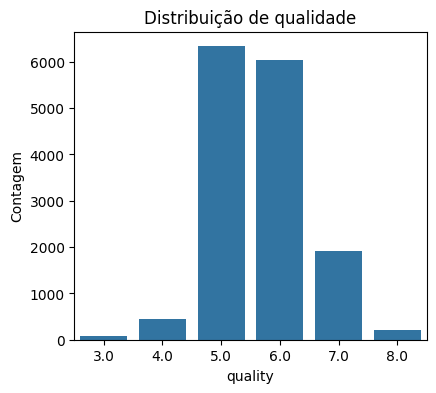

In [88]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.countplot(x='quality', data=train, stat = 'count')
plt.title('Distribuição de qualidade')
plt.xlabel('quality')
plt.ylabel('Contagem')
plt.show()

# Histograma coluna qualidade

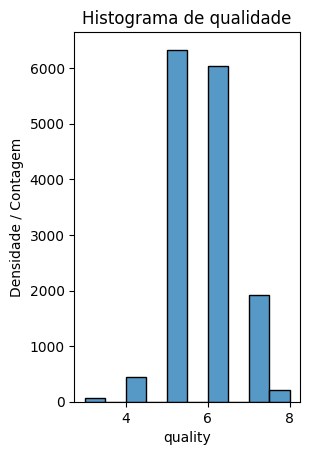

In [ ]:
plt.subplot(1,2,2)
sns.histplot(train['quality'], bins=10)
plt.title('Histograma de qualidade')
plt.xlabel('quality')
plt.ylabel('Densidade / Contagem')
plt.show()

# Histograma de todas as outras colunas

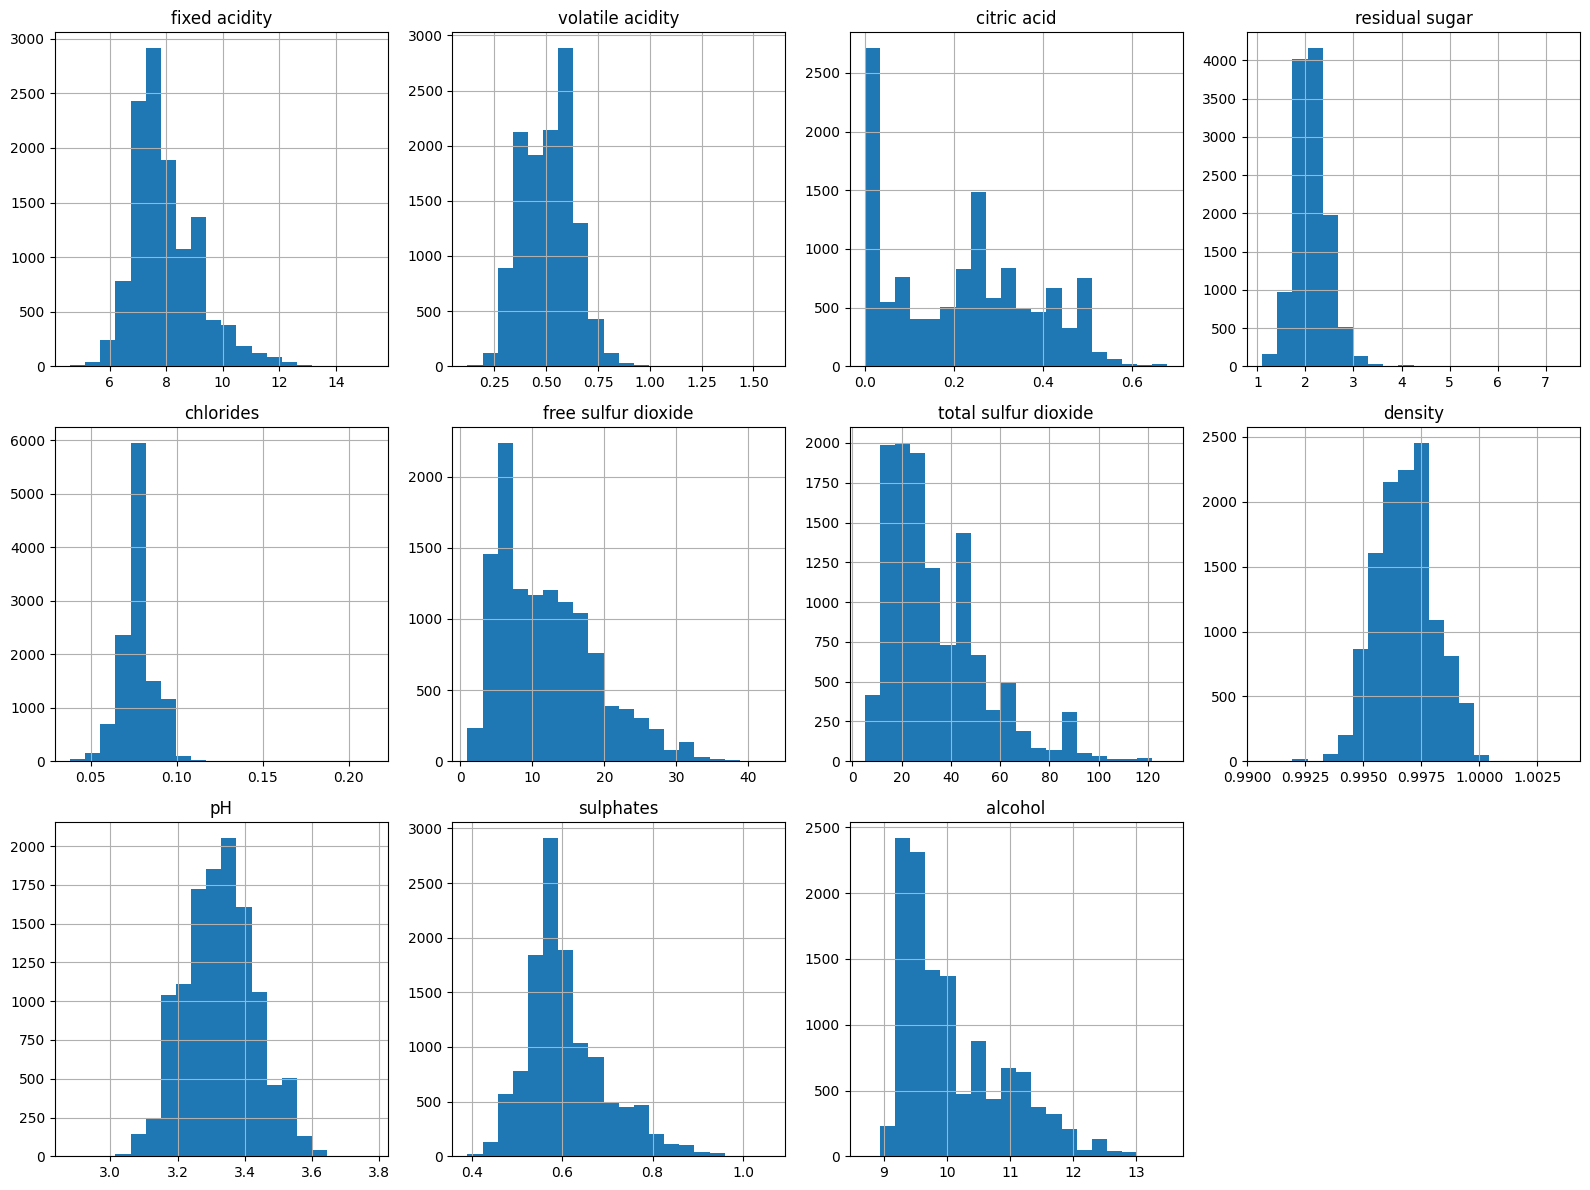

In [141]:
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
num_cols.remove('quality') # tira a coluna qualidade
train[num_cols].hist(bins=20, figsize=(16,12), layout=(int(np.ceil(len(num_cols)/4)),4))
plt.tight_layout()
plt.show()

# Boxplots para checar outliers por coluna

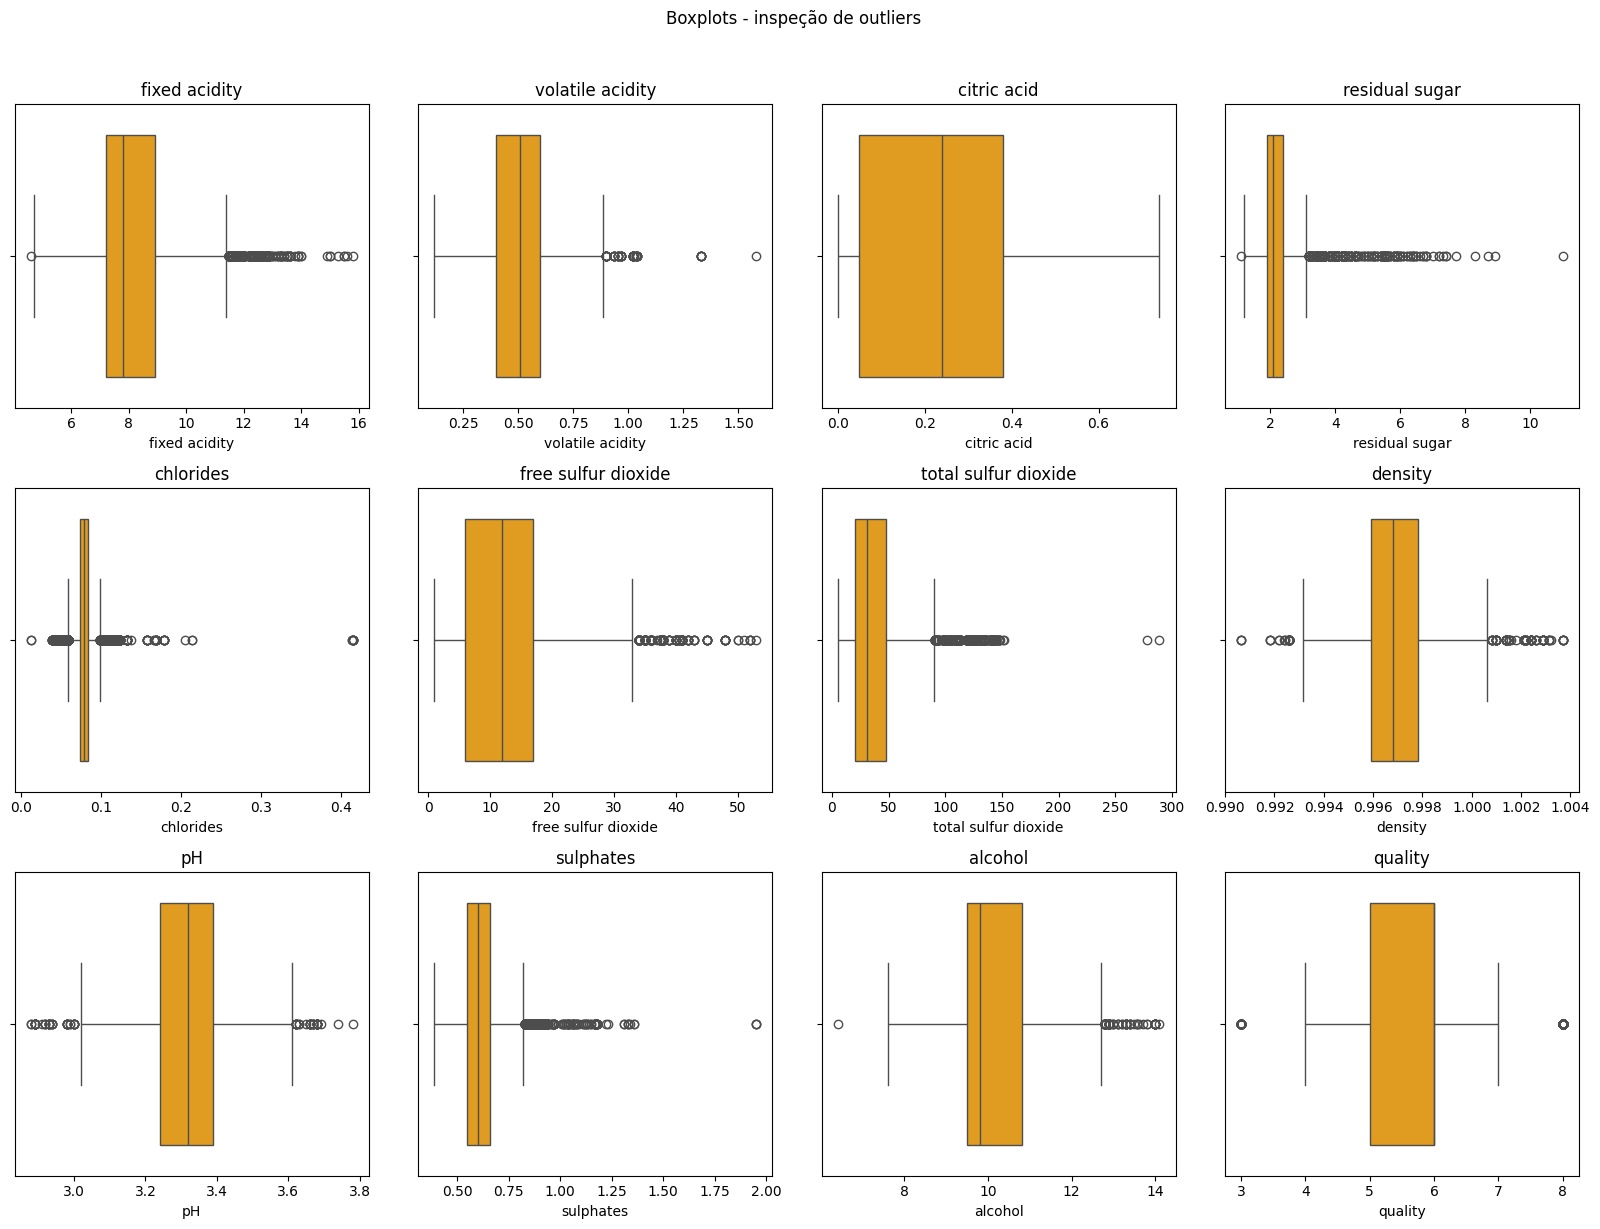

In [ ]:

plt.figure(figsize=(16,12))
cols_per_row = 4
rows = int(np.ceil(len(num_cols)/cols_per_row))
for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, cols_per_row, i)
    sns.boxplot(x=train[col], color='orange')
    plt.title(col)
plt.suptitle('Boxplots - inspeção de outliers', y=1.02)
plt.tight_layout()
plt.show()

# Remoção de outliers

In [ ]:
iso_forest = IsolationForest(contamination=0.2, random_state=42)
outlier_predictions = iso_forest.fit_predict(train)
train = train[outlier_predictions == 1] 


# Matriz de correlação entre colunas

In [ ]:
corr = train.corr()
corr 

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.296294,0.560044,0.041715,0.041040,-0.090268,-0.048116,0.161380,-0.368344,0.132283,-0.023512,-0.009701
volatile acidity,-0.296294,1.000000,-0.649510,-0.045086,-0.045546,-0.007609,-0.028037,-0.058297,0.215353,-0.162311,-0.028911,0.007783
citric acid,0.560044,-0.649510,1.000000,0.064834,0.063965,-0.008266,0.024209,0.137428,-0.396765,0.202818,0.018981,-0.009789
residual sugar,0.041715,-0.045086,0.064834,1.000000,0.037759,0.001302,0.011957,0.019552,-0.027934,0.007103,0.051348,0.011905
chlorides,0.041040,-0.045546,0.063965,0.037759,1.000000,0.017109,0.028227,0.045394,-0.032082,0.010540,-0.047913,-0.006268
free sulfur dioxide,-0.090268,-0.007609,-0.008266,0.001302,0.017109,1.000000,0.700982,-0.015760,0.018160,-0.018687,-0.081537,-0.034965
total sulfur dioxide,-0.048116,-0.028037,0.024209,0.011957,0.028227,0.700982,1.000000,0.017123,-0.004479,-0.024847,-0.175344,-0.095410
density,0.161380,-0.058297,0.137428,0.019552,0.045394,-0.015760,0.017123,1.000000,-0.042686,0.019420,-0.106139,-0.033375
pH,-0.368344,0.215353,-0.396765,-0.027934,-0.032082,0.018160,-0.004479,-0.042686,1.000000,-0.075867,0.010046,0.018812
sulphates,0.132283,-0.162311,0.202818,0.007103,0.010540,-0.018687,-0.024847,0.019420,-0.075867,1.000000,0.057610,0.055172


# Heatmap

<Axes: >

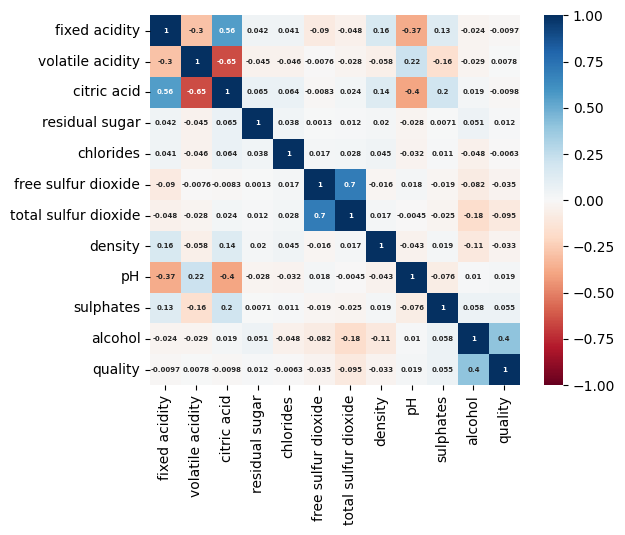

In [ ]:
sns.heatmap(corr,cmap = 'RdBu', vmin = -1.0, vmax = 1.0,annot=True,square=True, annot_kws = {'fontsize' : 5, 'fontweight' : 'bold'}) 


# Separar Atributos mais `Correlacionados `

In [95]:
corr_with_quality = abs(corr['quality']).sort_values(ascending=False) #ordenar por nivel de correlação com qualidade
print("Correlações com 'quality':") # correlação com o target qualidade (Y)
print(corr_with_quality)
important_features = corr_with_quality[corr_with_quality > 0.009].index.tolist() #pegar nossos candidatos pro valor de X, correlaçao > 0,05
important_features.remove('quality') #tirar qualidade dos candidatos

print("\nFeatures mais importantes:")
print(important_features) # mostrar candidatos pra analise

Correlações com 'quality':
quality                 1.000000
alcohol                 0.404455
total sulfur dioxide    0.095410
sulphates               0.055172
free sulfur dioxide     0.034965
density                 0.033375
pH                      0.018812
residual sugar          0.011905
citric acid             0.009789
fixed acidity           0.009701
volatile acidity        0.007783
chlorides               0.006268
Name: quality, dtype: float64

Features mais importantes:
['alcohol', 'total sulfur dioxide', 'sulphates', 'free sulfur dioxide', 'density', 'pH', 'residual sugar', 'citric acid', 'fixed acidity']


# Treinamento e Avaliacao com cada modelo proposto

```
- Linear Regression
- Random Forest
- Gradient Boosting 
```

In [96]:
X = train[important_features] #preparar X e y
y = train['quality']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.05, random_state=42) #80/20 e definicao de seed padrao 42 

scaler = RobustScaler() # normalizacao por StandardScaler 
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.fit_transform(X_val)

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42)
}

train_results = {} #dicionarios para armazenar resultados
val_results = {}

#treinar e avaliar cada modelo
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_train_pred = model.predict(X_train_scaled)
    y_val_pred = model.predict(X_val_scaled)
    train_results[name] = {
        'R2': r2_score(y_train, y_train_pred),
        'MAE': mean_absolute_error(y_train, y_train_pred),
        'RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred))
    }                   
    val_results[name] = {
        'R2': r2_score(y_val, y_val_pred,),
        'MAE': mean_absolute_error(y_val, y_val_pred),
        'RMSE': np.sqrt(mean_squared_error(y_val, y_val_pred))
    }

# Resultados de Treino


Resultados da Avaliação dos Modelos de treino:
      Linear Regression  Random Forest  Gradient Boosting
R2               0.1681         0.8806             0.2194
MAE              0.5450         0.2026             0.5303
RMSE             0.6613         0.2506             0.6406


<Figure size 1200x600 with 0 Axes>

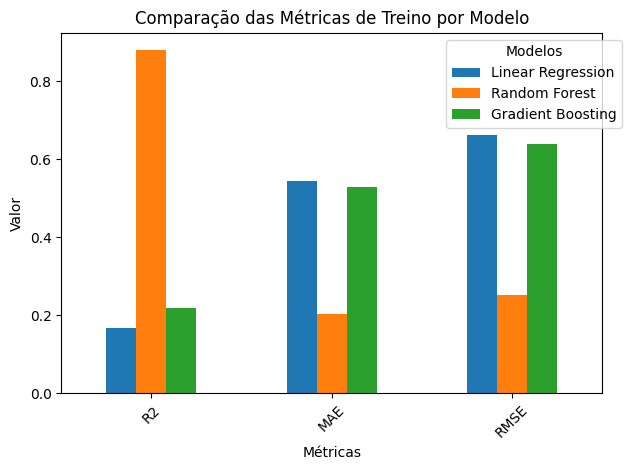

In [ ]:
train_results_df = pd.DataFrame(train_results).round(4) 
print("\nResultados da Avaliação dos Modelos de treino:")
print(train_results_df)
plt.figure(figsize=(12, 6)) #plotar os resultados
train_results_df.plot(kind='bar')
plt.title('Comparação das Métricas de Treino por Modelo')
plt.xlabel('Métricas')
plt.ylabel('Valor')
plt.xticks(rotation=45)
plt.legend(title='Modelos', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

# Resultados de Validacao


Resultados da Avaliação dos Modelos de validacao:
      Linear Regression  Random Forest  Gradient Boosting
R2               0.1351         0.0811             0.1400
MAE              0.5412         0.5516             0.5415
RMSE             0.6519         0.6719             0.6500


<Figure size 1200x600 with 0 Axes>

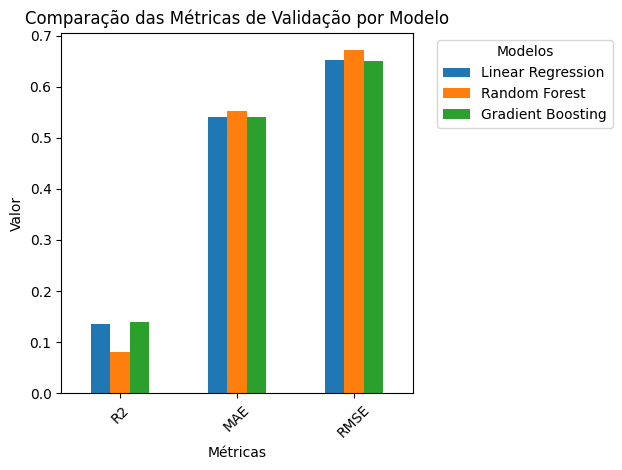

In [98]:
val_results_df = pd.DataFrame(val_results).round(4) #criar data frame pra mostrar resultados
print("\nResultados da Avaliação dos Modelos de validacao:")
print(val_results_df)
plt.figure(figsize=(12, 6)) #plotar os resultados
val_results_df.plot(kind='bar')
plt.title('Comparação das Métricas de Validação por Modelo')
plt.xlabel('Métricas')
plt.ylabel('Valor')
plt.xticks(rotation=45)
plt.legend(title='Modelos', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

# Selecao do(s) melhor(es) modelo(s):

```
- RMSE < 0.65
- R² > 0.35
- Diff RMSE < 0.15
```

In [ ]:

rmse_diff = {model: abs(train_results[model]['RMSE'] - val_results[model]['RMSE']) for model in models}
print('\nVerificação completa dos critérios:')
for model_name in models:
    print(f"\nModelo: {model_name}")
    rmse_ok = val_results[model_name]['RMSE'] < 0.651
    r2_ok = val_results[model_name]['R2'] > 0.35
    diff_ok = rmse_diff[model_name] < 0.15
    print(f"- RMSE < 0.65: {'sim' if rmse_ok else 'nao'} ({val_results[model_name]['RMSE']:.4f})")
    print(f"- R² > 0.35: {'sim' if r2_ok else 'nao'} ({val_results[model_name]['R2']:.4f})")
    print(f"- Diff RMSE < 0.15: {'sim' if diff_ok else 'nao'} ({rmse_diff[model_name]:.4f})")
    print(f"Todos critérios atendidos: {'sim' if (rmse_ok and r2_ok and diff_ok) else 'nao'}")


Verificação completa dos critérios:

Modelo: Linear Regression
- RMSE < 0.65: nao (0.6519)
- R² > 0.35: nao (0.1351)
- Diff RMSE < 0.15: sim (0.0095)
Todos critérios atendidos: nao

Modelo: Random Forest
- RMSE < 0.65: nao (0.6719)
- R² > 0.35: nao (0.0811)
- Diff RMSE < 0.15: nao (0.4214)
Todos critérios atendidos: nao

Modelo: Gradient Boosting
- RMSE < 0.65: sim (0.6500)
- R² > 0.35: nao (0.1400)
- Diff RMSE < 0.15: sim (0.0094)
Todos critérios atendidos: nao


**Modelo selecionado : Gradient Boosting**


# Definicao de K otimo utilizando Metodo do cotovelo

2 : 4.420431455085516
3 : 3.7526999855204424
4 : 3.423534601638483
5 : 3.1940703780942576


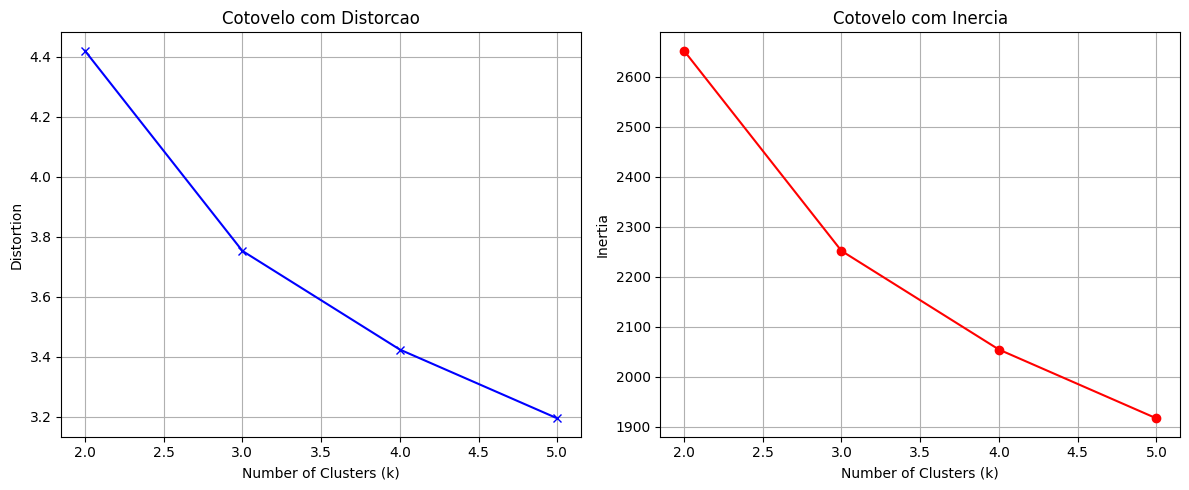

In [107]:
y_selected = models["Gradient Boosting"].predict(X_val_scaled)

# Aplicar PCA para reduzir a 2 dimensões para visualização
pca_viz = PCA(n_components=2)
X_pca = pca_viz.fit_transform(X_val_scaled)

K = range(2, 6)
distortion = []
inertia = []
mapping_distortion = {}
mapping_inertia = {}

for k in K:  # Testando para valores de K ótimo
    kmeanModel = KMeans(n_clusters=k, random_state=42).fit(X_val_scaled)
    
    distortion.append(sum(np.min(cdist(X_val_scaled, kmeanModel.cluster_centers_, 'euclidean'), axis=1)**2) / X_val_scaled.shape[0])
    inertia.append(kmeanModel.inertia_)
    
    mapping_distortion[k] = distortion[-1]
    mapping_inertia[k] = inertia[-1]
    
for key, val in mapping_distortion.items():
    print(f'{key} : {val}')

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(K, distortion, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Distortion')
plt.title('Cotovelo com Distorcao')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(K, inertia, 'ro-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Cotovelo com Inercia')
plt.grid()

plt.tight_layout()
plt.show()


# Geracao de Grafico de visualizacao de Clusters para analise final de K otimo

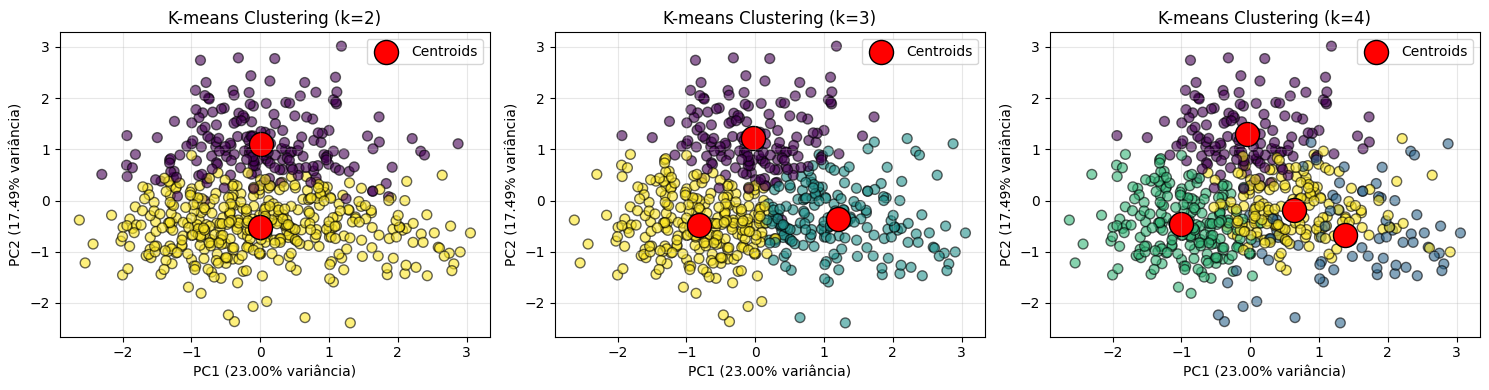


 K = 2 clusters
  Cluster 1: 191 elementos (31.83%)
  Cluster 2: 409 elementos (68.17%)
  Total: 600 elementos

 K = 3 clusters
  Cluster 1: 155 elementos (25.83%)
  Cluster 2: 182 elementos (30.33%)
  Cluster 3: 263 elementos (43.83%)
  Total: 600 elementos

 K = 4 clusters
  Cluster 1: 139 elementos (23.17%)
  Cluster 2: 75 elementos (12.50%)
  Cluster 3: 209 elementos (34.83%)
  Cluster 4: 177 elementos (29.50%)
  Total: 600 elementos


In [ ]:
k_range = range(2, 5)
# Range Sugerido pelo enunciado

plt.figure(figsize=(15, 4))

for idx, k in enumerate(k_range, 1):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    y_kmeans = kmeans.fit_predict(X_val_scaled)
    
    # Transformar centróides para o espaço PCA
    centers_pca = pca_viz.transform(kmeans.cluster_centers_)
    
    #Plotar grafico PCA
    
    plt.subplot(1, 3, idx)
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans, cmap='viridis', marker='o', edgecolor='k', s=50, alpha=0.6)
    plt.scatter(centers_pca[:, 0], centers_pca[:, 1], s=300, c='red', label='Centroids', edgecolor='k', marker='o')
    plt.title(f'K-means Clustering (k={k})')
    plt.xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]:.2%} variância)')
    plt.ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]:.2%} variância)')
    plt.legend()
    plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Mostrar quantidade de elementos por cluster pra cada K testado
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    y_kmeans = kmeans.fit_predict(X_val_scaled)
    
    unique, counts = np.unique(y_kmeans, return_counts=True)
    
    print(f"\n K = {k} clusters")
    total = 0
    for cluster_id, count in zip(unique, counts):
        percentage = (count / len(y_kmeans)) * 100
        print(f"  Cluster {cluster_id+1}: {count} elementos ({percentage:.2f}%)")
        total += count
    print(f"  Total: {total} elementos")


*K = 3 como K otimo*

In [110]:
# Análise da qualidade média por cluster (k=3)
optimal_k = 3
kmeans_optimal = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
clusters = kmeans_optimal.fit_predict(X_val_scaled)

# Criar dataframe com clusters e qualidades
analysis_df = pd.DataFrame({
    'Cluster': clusters,
    'Quality': y_val.values
})

# Calcular qualidade média por cluster
quality_by_cluster = analysis_df.groupby('Cluster')['Quality'].agg(['mean', 'std', 'count'])
print("\nQualidade Média por Cluster (k=3):")
print(quality_by_cluster)

# Encontrar cluster com maior qualidade média
best_cluster = quality_by_cluster['mean'].idxmax()
best_quality = quality_by_cluster.loc[best_cluster, 'mean']

print(f"\nCluster com MAIOR qualidade média: {best_cluster}")
print(f"Qualidade média: {best_quality:.4f}")
print(f"Número de elementos: {int(quality_by_cluster.loc[best_cluster, 'count'])}")
print(f"Desvio padrão: {quality_by_cluster.loc[best_cluster, 'std']:.4f}")

# Selecionar dados do cluster com melhor qualidade
best_cluster_data = analysis_df[analysis_df['Cluster'] == best_cluster]
print(f"\nDados selecionados do Cluster {best_cluster}:")
print(f"  Total de elementos: {len(best_cluster_data)}")
print(f"  Qualidade mínima: {best_cluster_data['Quality'].min():.4f}")
print(f"  Qualidade máxima: {best_cluster_data['Quality'].max():.4f}")



Qualidade Média por Cluster (k=3):
             mean       std  count
Cluster                           
0        5.503226  0.628069    155
1        5.664835  0.722775    182
2        5.695817  0.719588    263

Cluster com MAIOR qualidade média: 2
Qualidade média: 5.6958
Número de elementos: 263
Desvio padrão: 0.7196

Dados selecionados do Cluster 2:
  Total de elementos: 263
  Qualidade mínima: 4.0000
  Qualidade máxima: 8.0000


# Carregar CSV com atributos faltantes (Já fornecido) pra um dataframe
## E verificar se a porcentagem média de itens faltantes (~20%) esta sendo seguida pra todos os Atributos


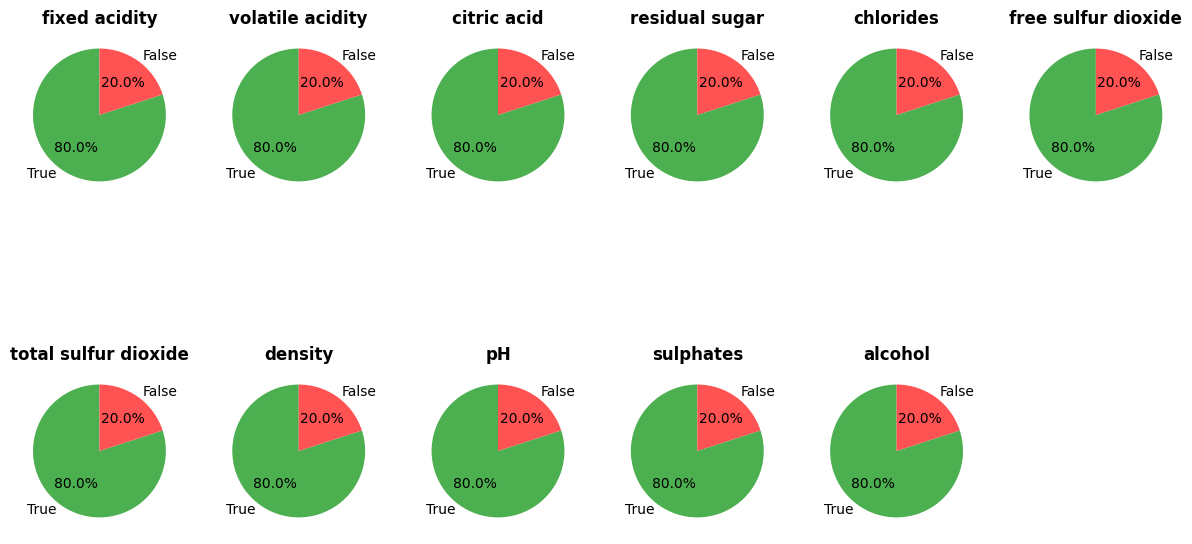

In [ ]:

missing = pd.read_csv("test_with_missing_features.csv",  index_col= 0)

control = 0
control = missing.notna() #Troca valores não vazios por True e valores vazios por False

n_cols_plot = 6
n_cols_df = len(control.columns)
n_rows_plot = (n_cols_df + n_cols_plot - 1) // n_cols_plot # Organizacao dos graficos (11) no total

# Criar a figura e os eixos
fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(15, 4 * n_rows_plot))
axes = axes.flatten() 

for i, col in enumerate(control.columns):
    # Contagem de True/False para a coluna atual do dataframe 'control'
    contagem = control[col].value_counts()
    axes[i].pie(contagem, 
                labels=contagem.index, 
                autopct='%1.1f%%', 
                startangle=90,
                colors=['#4CAF50', '#FF5252']) # Verde (True), Vermelho (False)
    
    axes[i].set_title(col, fontsize=12, fontweight='bold')

# Remover eixos que sobraram vazios no final do grid por não ser multiplo de 6
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])


plt.show()


- *Valores faltantes todos na faixa dos 20%*
- **Logo, podemos continuar**